In [ ]:
# NOTE : 02_A_Source_Identificaiton_Sorting_And_Photometry_Algorithm.ipynb - Cell 1
# This is for the unit tests only; will run the same pipeline used on V CrA on the unit tests first
# To ensure the processing integrity of SISaP.

# Runs the SAME two-pass (global + local, DASCH-style) calibration used on
# V CrA, but against the SYNTHETIC unit-test benchmark — so it can be scored
# against known ground truth via unit_Test_Generator.ipynb's validator.
# Self-contained: does not depend on execution order of other cells.

from pathlib import Path
from datetime import datetime
import pickle
import time
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.stats import SigmaClip
from photutils.aperture import (CircularAperture, CircularAnnulus,
                                 ApertureStats, aperture_photometry)
from photutils.centroids import centroid_sources, centroid_com
from photutils.background import Background2D, MedianBackground
import ipywidgets as widgets
from IPython.display import display

# Paths; synthetic benchmark, same location unit_Test_Generator.ipynb uses
UNIT_TEST_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests")
CUTOUTS_DIR = UNIT_TEST_DIR / 'cutouts'
CATALOG_PATH = UNIT_TEST_DIR / 'synthetic_catalog.csv'

# Output folder MUST match the prefix unit_Test_Generator.ipynb's Cell 2
# auto-discovers: find_latest_algorithm_run(prefix='test_Algorithm_')
RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = UNIT_TEST_DIR / f'test_Algorithm_{RUN_TIMESTAMP}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Separate cache from Cell 1's original synthetic pipeline, since this is
# testing a DIFFERENT calibration methodology (two-pass local vs. single
# global quadratic) and shouldn't share/overwrite that cache.
CACHE_DIR = UNIT_TEST_DIR / 'algorithm_cache_twopass'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = OUTPUT_DIR / 'algorithm_photometry_results.csv'
LIGHTCURVE_PATH = OUTPUT_DIR / 'algorithm_lightcurve.csv'
REF_PHOTOMETRY_PATH = OUTPUT_DIR / 'algorithm_reference_photometry.csv'

print(f"This run's output folder: {OUTPUT_DIR}")
print("(matches unit_Test_Generator.ipynb's test_Algorithm_* auto-discovery)")

# Parameters / variables for photometry
DEFAULT_APERTURE = 6
ANNULUS_INNER = 15
ANNULUS_OUTER = 20
CENTROID_BOX = 21
CENTROID_MAX_DRIFT = 5   # confirmed reverted from 12 (same crowding-
                          # contamination regression already diagnosed on
                          # V CrA).
SIGNIF_THRESHOLD = 5.0
SATURATION_FRACTION = 0.99
SATURATION_MIN_PIXELS = 5
ISOLATION_MIN_SEPARATION = ANNULUS_OUTER + 2
OUTLIER_SIGMA = 3.0
REF_STARS_MAX_PER_PLATE = 150

# Global (spatial) calibration
MIN_REF_STARS = 25

# Local (magnitude-dependent) calibration — same DASCH-style approach as V CrA
LOCAL_HALF_WINDOW = 1.5
MIN_REF_STARS_LOCAL = 8
LOCAL_WINDOW_GROWTH = 1.6
MIN_ABS_LOCAL_SLOPE = 0.3
MAX_LOCAL_GLOBAL_JUMP = 999  # disabled — ruled out as a cause; global
                              # estimate itself isn't reliable enough to
                              # gate against.

# Quality gating on the FINAL calibration RMS
MAX_CALIBRATION_RMS = 0.3

VERSION = 5  # bumped from 4: quality_ok now REQUIRES calibration_mode ==
             # 'local'. Ground-truth validation confirmed local-mode plates
             # have a median true error of only 0.012 mag (excellent), while
             # global_fallback plates have a mean true error of ~7.0 mag
             # (catastrophic) — 3 of 38 fallback plates were slipping
             # through the RMS gate by chance and corrupting the aggregate
             # accuracy. Fallback is no longer eligible for inclusion in the
             # light curve at all, regardless of its own RMS.

# Loads catalog
catalog = pd.read_csv(CATALOG_PATH)
target_row = catalog[catalog['is_target'] == True].iloc[0]
TARGET_COORD = SkyCoord(ra=target_row['ra'] * u.deg, dec=target_row['dec'] * u.deg)

# Exclude phantom stars; confirmed root-cause fix from earlier debugging
ref_catalog = catalog[(catalog['is_target'] == False) & (catalog['is_phantom'] == False)].copy()
print(f"Loaded catalog: {len(catalog)} stars ({len(ref_catalog)} non-phantom reference candidates)")
print(f"Target coordinate: RA={TARGET_COORD.ra.deg:.6f}, Dec={TARGET_COORD.dec.deg:.6f}")

cutouts = sorted(CUTOUTS_DIR.glob("*.fits"))
print(f"Found {len(cutouts)} synthetic plates to process")

def load_cache(name, default=None):
    path = CACHE_DIR / f"{name}.pkl"
    if path.exists():
        try:
            with open(path, 'rb') as f:
                return pickle.load(f)
        except Exception:
            pass
    return default if default is not None else {}

def save_cache(name, data):
    with open(CACHE_DIR / f"{name}.pkl", 'wb') as f:
        pickle.dump(data, f)

plate_db = load_cache('plate_db', {})
print(f"Loaded {len(plate_db)} cached plate results")

# Photometry functions
def subtract_background_2d(data, box_size=50):
    try:
        bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3),
                            bkg_estimator=MedianBackground())
        return data - bkg.background, bkg.background_rms
    except Exception:
        med = np.nanmedian(data)
        return data - med, np.full_like(data, np.nanstd(data))

def refine_centroids(data, x, y, box_size=CENTROID_BOX, max_drift=CENTROID_MAX_DRIFT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0:
        return x, y
    try:
        x_ref, y_ref = centroid_sources(data, x, y, box_size=box_size,
                                         centroid_func=centroid_com)
        good = np.isfinite(x_ref) & np.isfinite(y_ref)
        drift = np.hypot(x_ref - x, y_ref - y)
        good &= drift < max_drift
        x_ref[~good] = x[~good]
        y_ref[~good] = y[~good]
        return x_ref, y_ref
    except Exception:
        return x, y

def filter_isolated_stars(x, y, min_separation=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_separation):
            isolated[i] = False
    return isolated

def measure_aperture_photometry(data, x, y, radius=DEFAULT_APERTURE,
                                 annulus_inner=ANNULUS_INNER, annulus_outer=ANNULUS_OUTER):
    n = len(x)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    annulus = CircularAnnulus(positions, r_in=annulus_inner, r_out=annulus_outer)
    ann_stats = ApertureStats(data, annulus, sigma_clip=SigmaClip(sigma=3.0))
    bkg_median = np.nan_to_num(ann_stats.median, nan=0.0)
    bkg_std = np.nan_to_num(ann_stats.std, nan=0.0)
    phot = aperture_photometry(data, aperture)
    flux = phot['aperture_sum'].value - bkg_median * (np.pi * radius**2)
    return flux, bkg_median, bkg_std

def detect_saturation(data, x, y, radius=DEFAULT_APERTURE,
                       sat_fraction=SATURATION_FRACTION, min_pixels=SATURATION_MIN_PIXELS):
    n = len(x)
    is_sat = np.zeros(n, dtype=bool)
    data_max = np.nanmax(data)
    if data_max <= 0:
        return is_sat
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    aperture_masks = aperture.to_mask(method='center')
    for i in range(n):
        mask = aperture_masks[i]
        cut = mask.multiply(data)
        if cut is None:
            continue
        star_pixels = cut[mask.data > 0]
        if len(star_pixels) == 0:
            continue
        near_max = np.sum(star_pixels >= sat_fraction * data_max)
        is_sat[i] = near_max >= min_pixels
    return is_sat

# Two pass calibration for the target (V CrA)
def calibrate_global(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x = apass_b[mask]
    y = inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH, outlier_sigma=OUTLIER_SIGMA):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None

    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None

    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    coeffs = list(calibration['coeffs'])
    coeffs[-1] = coeffs[-1] - t_inst_mag
    roots = np.roots(coeffs)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    best = min(candidates, key=lambda r: abs(np.polyval(calibration['coeffs'], r) - t_inst_mag))
    return float(best)


# Processing per plate
def process_synthetic_plate_twopass(fits_path):
    try:
        # Deterministic, per-plate RNG derived from the filename; fixes a
        # confirmed bug where the previous unseeded np.random.choice() call
        # (used when a plate has more than REF_STARS_MAX_PER_PLATE candidate
        # reference stars) produced a DIFFERENT random subsample every time
        # the SAME plate was reprocessed, causing wildly different results.
        plate_rng = np.random.default_rng(abs(hash(fits_path.name)) % (2**32))

        data = astrofits.getdata(fits_path).astype(float)
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = header.get('JD-OBS', np.nan)

        data_sub, bkg_rms = subtract_background_2d(data)

        ra = ref_catalog['ra'].values
        dec = ref_catalog['dec'].values
        star_ids = ref_catalog['id'].values
        apass_b = ref_catalog['apass_b_mag'].values

        x, y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (x > margin) & (x < data.shape[1] - margin) & \
                   (y > margin) & (y < data.shape[0] - margin)
        x, y = x[in_frame], y[in_frame]
        star_ids = star_ids[in_frame]
        apass_b = apass_b[in_frame]

        if len(x) > REF_STARS_MAX_PER_PLATE:
            keep = plate_rng.choice(len(x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            x, y = x[keep], y[keep]
            star_ids = star_ids[keep]
            apass_b = apass_b[keep]

        if len(x) == 0:
            return _empty_result(fits_path, jd, 'No reference stars in frame')

        x_ref, y_ref = refine_centroids(data_sub, x, y)
        isolated = filter_isolated_stars(x_ref, y_ref)
        flux, bkg_med, bkg_std = measure_aperture_photometry(data_sub, x_ref, y_ref)

        area = np.pi * DEFAULT_APERTURE**2
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.where(bkg_std > 0, flux / (bkg_std * np.sqrt(area)), 0)

        is_sat = detect_saturation(data, x_ref, y_ref)
        with np.errstate(divide='ignore', invalid='ignore'):
            inst_mag = np.where(flux > 0, -2.5 * np.log10(np.maximum(flux, 1e-10)), np.nan)

        good_for_fit = (snr >= SIGNIF_THRESHOLD) & np.isfinite(inst_mag) & ~is_sat & isolated
        fit_inst_mag = inst_mag[good_for_fit]
        fit_apass_b = apass_b[good_for_fit]

        calibration_global = calibrate_global(fit_inst_mag, fit_apass_b)
        n_ref_used = calibration_global['n_used'] if calibration_global else int(good_for_fit.sum())

        ref_rows = []
        for i in range(len(x_ref)):
            if np.isfinite(inst_mag[i]) and snr[i] >= SIGNIF_THRESHOLD and isolated[i]:
                ref_rows.append({
                    'filename': fits_path.name,
                    'star_id': star_ids[i],
                    'apass_b_mag': apass_b[i],
                    'instrumental_mag': inst_mag[i]
                })

        tx, ty = wcs.all_world2pix(TARGET_COORD.ra.deg, TARGET_COORD.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        if margin < tx < data.shape[1] - margin and margin < ty < data.shape[0] - margin:
            tx_ref, ty_ref = refine_centroids(data_sub, np.array([tx]), np.array([ty]))
            t_flux, t_bkg_med, t_bkg_std = measure_aperture_photometry(data_sub, tx_ref, ty_ref)
            t_area = np.pi * DEFAULT_APERTURE**2
            t_snr = t_flux[0] / (t_bkg_std[0] * np.sqrt(t_area)) if t_bkg_std[0] > 0 else 0

            if t_snr >= SIGNIF_THRESHOLD and t_flux[0] > 0 and calibration_global is not None:
                t_inst_mag = -2.5 * np.log10(t_flux[0])
                rough_mag = invert_calibration(calibration_global, t_inst_mag)

                if rough_mag is not None:
                    calibration_local = calibrate_local(fit_inst_mag, fit_apass_b, rough_mag)

                    if (calibration_local is not None
                            and abs(calibration_local['coeffs'][0]) >= MIN_ABS_LOCAL_SLOPE):
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if (local_mag is not None
                                and abs(local_mag - rough_mag) <= MAX_LOCAL_GLOBAL_JUMP):
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'

                    if calibration_mode is None:
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'

                    calibration_uncertainty = final_rms / np.sqrt(max(final_n_used, 1))
                    target_mag_error = np.sqrt((1.0857 / max(t_snr, 1e-6))**2 + calibration_uncertainty**2)
                    target_detected = True

                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
            else:
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
        else:
            tx_out, ty_out = np.nan, np.nan

        # global_fallback has a confirmed mean true error of ~7 mag —
        # never trustworthy enough to include, even when it happens to
        # clear the RMS gate by chance (3 of 38 fallback plates did).
        quality_ok = (
            calibration_global is not None and
            n_ref_used >= MIN_REF_STARS and
            target_detected and
            calibration_mode == 'local' and
            np.isfinite(final_rms) and
            final_rms <= MAX_CALIBRATION_RMS
        )

        result_row = {
            'filename': fits_path.name,
            'jd': jd,
            'target_detected': target_detected,
            'target_mag': target_mag,
            'target_mag_error': target_mag_error,
            'target_x': tx_out,
            'target_y': ty_out,
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'rms_scatter_global': calibration_global['rms'] if calibration_global else np.nan,
            'calibration_mode': calibration_mode,
            'quality_ok': quality_ok,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows}

    except Exception as e:
        print(f"Error processing {fits_path.name}: {e}")
        return _empty_result(fits_path, np.nan, str(e))

def _empty_result(fits_path, jd, reason):
    return {
        'result_row': {
            'filename': fits_path.name, 'jd': jd, 'target_detected': False,
            'target_mag': np.nan, 'target_mag_error': np.nan,
            'target_x': np.nan, 'target_y': np.nan,
            'num_reference_stars': 0, 'zeropoint': np.nan,
            'rms_scatter': np.nan, 'rms_scatter_global': np.nan,
            'calibration_mode': None, 'quality_ok': False,
        },
        'ref_rows': [],
    }

# Runs pipeline, shows progress bar, and saves plots
progress_bar = widgets.IntProgress(value=0, min=0, max=len(cutouts), description='Processing:')
progress_html = widgets.HTML(value="")
progress_status = widgets.Label(value="Not started")
display(widgets.VBox([progress_bar, progress_html, progress_status]))

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def render_progress(n_done, total, start_time):
    elapsed = time.monotonic() - start_time
    pct = (n_done / total * 100) if total else 0
    rate = (n_done / elapsed) if elapsed > 0 and n_done > 0 else 0
    remaining = ((total - n_done) / rate) if rate > 0 else None
    progress_bar.value = n_done
    progress_html.value = (
        f"<div style='font-family: monospace; font-size: 13px;'>"
        f"<b>{pct:5.1f}%</b> &nbsp; {n_done:,} / {total:,} plates &nbsp;|&nbsp; "
        f"{rate:.2f} plates/sec &nbsp;|&nbsp; "
        f"Elapsed {format_eta(elapsed)} &nbsp;|&nbsp; ETA {format_eta(remaining)}"
        f"</div>"
    )

def run_pipeline(force_reprocess=False):
    global plate_db
    total = max(len(cutouts), 1)
    progress_bar.max = total
    progress_bar.value = 0
    start = time.monotonic()
    last_render = 0.0
    n_errors = 0

    for i, f in enumerate(cutouts):
        key = str(f)
        cached = plate_db.get(key)
        if not force_reprocess and cached and cached.get('_version', 0) == VERSION:
            pass
        else:
            progress_status.value = f"Processing: {f.name}"
            out = process_synthetic_plate_twopass(f)
            if out['result_row'].get('num_reference_stars', 0) == 0:
                n_errors += 1
            out['_version'] = VERSION
            plate_db[key] = out

        now = time.monotonic()
        if now - last_render > 0.15 or (i + 1) == total:
            render_progress(i + 1, total, start)
            last_render = now

        if (i + 1) % 500 == 0:
            save_cache('plate_db', plate_db)

    save_cache('plate_db', plate_db)
    progress_status.value = f"Done. {len(plate_db)} plates in cache ({n_errors} flagged with no usable reference stars)."
    print(progress_status.value)
    return _save_outputs()

def _save_outputs():
    result_rows, ref_rows_all = [], []
    for f_str, out in plate_db.items():
        if out is None:
            continue
        result_rows.append(out['result_row'])
        ref_rows_all.extend(out['ref_rows'])

    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Saved {RESULTS_PATH.name} ({len(results_df)} plates)")

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(REF_PHOTOMETRY_PATH, index=False)
    print(f"Saved {REF_PHOTOMETRY_PATH.name} ({len(ref_df)} reference measurements)")

    if 'calibration_mode' in results_df.columns:
        print(f"  Calibration mode breakdown: {results_df['calibration_mode'].value_counts(dropna=False).to_dict()}")

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna()
    lc_df.to_csv(LIGHTCURVE_PATH, index=False)
    print(f"Saved {LIGHTCURVE_PATH.name} ({len(lc_df)} light curve points)")

    return results_df, ref_df, lc_df

results_df, ref_df, lc_df = run_pipeline(force_reprocess=False)

# RMS self check
if len(results_df) > 0 and 'rms_scatter' in results_df.columns:
    rms_vals = results_df['rms_scatter'].dropna()
    if len(rms_vals) > 0:
        print("\n" + "=" * 60)
        print("FINAL CALIBRATION RMS DISTRIBUTION")
        print("=" * 60)
        print(rms_vals.describe(percentiles=[.25, .5, .6, .7, .75, .9]))
        print(f"\nCurrent MAX_CALIBRATION_RMS = {MAX_CALIBRATION_RMS} "
              f"-> {(rms_vals <= MAX_CALIBRATION_RMS).sum()} / {len(rms_vals)} plates pass this gate")

print("\n" + "=" * 70)
print("Done. To validate against ground truth:")
print("  1. Open unit_Test_Generator.ipynb")
print("  2. Set USE_SIMULATED_INPUTS = False")
print(f"  3. Run Cell 2 — it will auto-discover: {OUTPUT_DIR.name}")
print("=" * 70)

KeyboardInterrupt: 

In [ ]:
# NOTE : 02_A_Source_Identificaiton_Sorting_And_Photometry_Algorithm.ipynb - Cell 2
# V CrA; Full Pipeline + DASCH Comparison (single self-contained cell)

# Two-pass calibration: global (spatial) fit for a rough estimate, then a
# DASCH-style local magnitude-dependent calibration for the final value;
# per Tang, Grindlay, Los & Servillat (2013, PASP 125, 857), the local pass
# is what drove their biggest RMS improvement (~0.15 -> ~0.10-0.12 mag).

from pathlib import Path
from datetime import datetime
import shelve
import time
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.stats import SigmaClip, sigma_clip
import astropy.units as u
from photutils.aperture import (CircularAperture, CircularAnnulus,
                                 ApertureStats, aperture_photometry)
from photutils.centroids import centroid_sources, centroid_com
from photutils.background import Background2D, MedianBackground
import ipywidgets as widgets
from IPython.display import display
import urllib.request
import urllib.parse

# Paths
V_CRA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA")
VCRA_CUTOUTS_DIR = V_CRA_DIR / 'cutouts'

VCRA_OUTPUT_DIR = V_CRA_DIR / '02_A'
VCRA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VCRA_CACHE_DIR = V_CRA_DIR / 'algorithm_cache'
VCRA_CACHE_DIR.mkdir(parents=True, exist_ok=True)

VCRA_RESULTS_PATH = VCRA_OUTPUT_DIR / 'vcra_photometry_results.csv'
VCRA_LIGHTCURVE_PATH = VCRA_OUTPUT_DIR / 'vcra_lightcurve.csv'
VCRA_REF_PHOTOMETRY_PATH = VCRA_OUTPUT_DIR / 'vcra_reference_photometry.csv'

print(f"V CrA run output folder: {VCRA_OUTPUT_DIR}")

# Photometry parameters
DEFAULT_APERTURE = 6
ANNULUS_INNER = 15
ANNULUS_OUTER = 20
CENTROID_BOX = 21
CENTROID_MAX_DRIFT = 5
SIGNIF_THRESHOLD = 5.0
SATURATION_FRACTION = 0.99
SATURATION_MIN_PIXELS = 5
ISOLATION_MIN_SEPARATION = ANNULUS_OUTER + 2
OUTLIER_SIGMA = 3.0
REF_STARS_MAX_PER_PLATE = 150

# Global (spatial) calibration; pass 1, gives a rough magnitude estimate
MIN_REF_STARS = 25

# Local (magnitude-dependent) calibration; pass 2, DASCH-style
LOCAL_HALF_WINDOW = 1.5     # +/- mag window around the rough estimate
MIN_REF_STARS_LOCAL = 8     # minimum stars needed within the window
LOCAL_WINDOW_GROWTH = 1.6   # widen the window by this factor if too few stars

# Quality gating on the FINAL (local-if-available) calibration RMS
MAX_CALIBRATION_RMS = 0.5   # starting guess — see the printed RMS
                             # distribution after the run; DASCH's own
                             # published median is ~0.10-0.12 mag, so this
                             # can likely be tightened once local
                             # calibration is confirmed working.

# Physically-motivated sanity bound on the FINAL light curve, informed by
# V CrA's actual documented range (9.4-17.9 mag per AAVSO/literature).
# ~2 mag of margin on each side still allows the archive to reveal a
# genuine new extreme, while catching computational artifacts (bad
# background subtraction, near-zero flux edge cases) that aren't real
# photometry. The statistical sigma-clip below is relative to LOCAL
# context and can miss an outlier sitting in a sparse-data stretch; this
# is an absolute physical check on top of it, not instead of it.
VCRA_SANITY_MAG_MIN = 7.0
VCRA_SANITY_MAG_MAX = 20.0

VCRA_VERSION = 10  # bumped: last change fixed a real bug where the target was missed
                   # entirely whenever it was brighter than every reference
                   # star used for calibration. The quadratic global fit's
                   # inversion has no real root when asked to extrapolate
                   # past its own fitted range, silently discarding an
                   # otherwise perfectly good detection. Now falls back to
                   # the nearest edge of the fit's range as a rough
                   # starting point instead of giving up outright.
VCRA_TARGET_COORD = SkyCoord(ra=281.884623417 * u.deg, dec=-38.158974417 * u.deg)
MIN_APASS_STARS_QUERY = 10

# Cache accessing and creation
VCRA_PLATE_DB_PATH = VCRA_CACHE_DIR / 'plate_db_shelf'
VCRA_APASS_CACHE_PATH = VCRA_CACHE_DIR / 'apass_cache_shelf'

vcra_plate_db = shelve.open(str(VCRA_PLATE_DB_PATH), flag='c', writeback=False)
apass_cache = shelve.open(str(VCRA_APASS_CACHE_PATH), flag='c', writeback=False)

print(f"Loaded {len(vcra_plate_db)} cached plate results, {len(apass_cache)} cached APASS field queries")

vcra_cutouts = sorted(VCRA_CUTOUTS_DIR.glob("*.fits"))
print(f"Found {len(vcra_cutouts)} V CrA plates in {VCRA_CUTOUTS_DIR}")

# Photometry functions
def subtract_background_2d(data, box_size=50):
    try:
        bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3),
                            bkg_estimator=MedianBackground())
        return data - bkg.background, bkg.background_rms
    except Exception:
        med = np.nanmedian(data)
        return data - med, np.full_like(data, np.nanstd(data))

def refine_centroids(data, x, y, box_size=CENTROID_BOX, max_drift=CENTROID_MAX_DRIFT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0:
        return x, y
    try:
        x_ref, y_ref = centroid_sources(data, x, y, box_size=box_size,
                                         centroid_func=centroid_com)
        good = np.isfinite(x_ref) & np.isfinite(y_ref)
        drift = np.hypot(x_ref - x, y_ref - y)
        good &= drift < max_drift
        x_ref[~good] = x[~good]
        y_ref[~good] = y[~good]
        return x_ref, y_ref
    except Exception:
        return x, y

def filter_isolated_stars(x, y, min_separation=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_separation):
            isolated[i] = False
    return isolated

def measure_aperture_photometry(data, x, y, radius=DEFAULT_APERTURE,
                                 annulus_inner=ANNULUS_INNER, annulus_outer=ANNULUS_OUTER):
    n = len(x)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    annulus = CircularAnnulus(positions, r_in=annulus_inner, r_out=annulus_outer)
    ann_stats = ApertureStats(data, annulus, sigma_clip=SigmaClip(sigma=3.0))
    bkg_median = np.nan_to_num(ann_stats.median, nan=0.0)
    bkg_std = np.nan_to_num(ann_stats.std, nan=0.0)
    phot = aperture_photometry(data, aperture)
    flux = phot['aperture_sum'].value - bkg_median * (np.pi * radius**2)
    return flux, bkg_median, bkg_std

def detect_saturation(data, x, y, radius=DEFAULT_APERTURE,
                       sat_fraction=SATURATION_FRACTION, min_pixels=SATURATION_MIN_PIXELS):
    n = len(x)
    is_sat = np.zeros(n, dtype=bool)
    # Was np.nanmax(data). A single hot pixel or cosmic ray hit anywhere
    # on the plate inflates that value, which then makes genuinely
    # saturated stars never reach "sat_fraction of max" and saturation
    # detection silently stops working for that plate. The 99.9th
    # percentile of the whole image is far more robust to a handful of
    # anomalous pixels while still tracking the real bright-star ceiling.
    data_max = np.nanpercentile(data, 99.9)
    if data_max <= 0:
        return is_sat
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    aperture_masks = aperture.to_mask(method='center')
    for i in range(n):
        mask = aperture_masks[i]
        cut = mask.multiply(data)
        if cut is None:
            continue
        star_pixels = cut[mask.data > 0]
        if len(star_pixels) == 0:
            continue
        near_max = np.sum(star_pixels >= sat_fraction * data_max)
        is_sat[i] = near_max >= min_pixels
    return is_sat


# Two pass calibration
def calibrate_global(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    """
    Pass 1: quadratic fit across the FULL magnitude range of reference
    stars on this plate. Captures the plate's overall non-linear response,
    used only to get a rough magnitude estimate for the local pass below.
    """
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x = apass_b[mask]
    y = inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH, outlier_sigma=OUTLIER_SIGMA):
    """
    Pass 2 (DASCH-style): linear fit using ONLY reference stars within a
    magnitude window around the target's expected brightness, rather than
    the plate's full dynamic range. A plate's response curve is not
    perfectly captured by one global polynomial — stars near the target's
    own brightness calibrate it better than the average across the whole
    range. Widens the window progressively if too few stars fall inside it.
    """
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None

    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None  # not enough local coverage anywhere reasonable

    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    """
    Solve calibration polynomial(B) = t_inst_mag for B. Works for any
    polynomial degree (linear local fit or quadratic global fit) via
    np.roots, picking the real root nearest the magnitude range the fit
    was actually built on.
    """
    roots = np.roots(list(calibration['coeffs']) + [-t_inst_mag] if False else
                      np.polynomial.polynomial.polyfromroots  # placeholder unused
                      ) if False else None
    # (explicit, readable version below — the above line is intentionally
    # unused; kept simple rather than clever)
    coeffs = calibration['coeffs']
    poly = list(coeffs)
    poly[-1] = poly[-1] - t_inst_mag  # subtract target value from constant term
    roots = np.roots(poly)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    best = min(candidates, key=lambda r: abs(np.polyval(coeffs, r) - t_inst_mag))
    return float(best)



# APASS query
def query_apass(ra_c, dec_c, radius_arcsec, max_rows=3000):
    params = {
        '-source': 'II/336/apass9',
        '-c': f"{ra_c} {dec_c}",
        '-c.rs': radius_arcsec,
        '-out': 'RAJ2000,DEJ2000,Bmag,e_Bmag',
        '-out.max': max_rows,
    }
    url = "https://vizier.cds.unistra.fr/viz-bin/asu-tsv?" + urllib.parse.urlencode(params)
    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as response:
                return response.read().decode('utf-8')
        except Exception:
            time.sleep(2 ** attempt)
    return None

def parse_apass_tsv(text):
    rows = []
    for line in text.split('\n'):
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-'):
            continue
        parts = line.split('\t')
        if len(parts) < 4:
            continue
        try:
            ra, dec, bmag, e_bmag = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            rows.append((ra, dec, bmag, e_bmag))
        except (ValueError, IndexError):
            continue
    if rows and not (0 < rows[0][2] < 25):
        rows = rows[1:]
    return rows

def get_field_catalog(ra_c, dec_c, radius_arcsec):
    key = f"{round(ra_c, 3)}_{round(dec_c, 3)}"
    if key in apass_cache:
        return apass_cache[key]
    raw = query_apass(ra_c, dec_c, radius_arcsec)
    rows = []
    if raw:
        rows = parse_apass_tsv(raw)
        rows = [r for r in rows if 0 < r[2] < 20 and r[3] < 0.5]
    apass_cache[key] = rows
    return rows


# Per plate processing
def get_plate_jd(header):
    if 'JD-OBS' in header:
        return float(header['JD-OBS'])
    if 'MJD-OBS' in header:
        return float(header['MJD-OBS']) + 2400000.5
    for key in ('DATE-OBS', 'DATE'):
        if key in header:
            try:
                return Time(header[key]).jd
            except Exception:
                continue
    return np.nan

def process_vcra_plate(fits_path):
    try:
        data = astrofits.getdata(fits_path).astype(float)
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = get_plate_jd(header)
        data_sub, bkg_rms = subtract_background_2d(data)

        h, w = data.shape
        ra_c, dec_c = wcs.all_pix2world(w / 2, h / 2, 0)
        corners_x = [0, w - 1, 0, w - 1]
        corners_y = [0, 0, h - 1, h - 1]
        corner_ra, corner_dec = wcs.all_pix2world(corners_x, corners_y, 0)
        center = SkyCoord(float(ra_c) * u.deg, float(dec_c) * u.deg)
        corners_sky = SkyCoord(corner_ra * u.deg, corner_dec * u.deg)
        field_radius_arcsec = center.separation(corners_sky).max().arcsec * 1.05

        apass_stars = get_field_catalog(float(ra_c), float(dec_c), field_radius_arcsec)
        if len(apass_stars) < MIN_APASS_STARS_QUERY:
            return _empty_vcra_result(fits_path, jd, 'Too few APASS stars in field')

        ra = np.array([s[0] for s in apass_stars])
        dec = np.array([s[1] for s in apass_stars])
        apass_b = np.array([s[2] for s in apass_stars])

        x, y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (x > margin) & (x < w - margin) & (y > margin) & (y < h - margin)
        x, y, apass_b = x[in_frame], y[in_frame], apass_b[in_frame]
        star_ids = np.array([f'APASS_{i:05d}' for i in range(len(x))])

        if len(x) > REF_STARS_MAX_PER_PLATE:
            # Seeded per-plate (was unseeded np.random.choice) so re-running
            # the same plate always picks the same subsample - otherwise
            # reprocessing the same data gives slightly different results
            # every time purely from random sampling, not from any real
            # change.
            rng = np.random.default_rng(abs(hash(fits_path.name)) % (2**32))
            keep = rng.choice(len(x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            x, y, apass_b, star_ids = x[keep], y[keep], apass_b[keep], star_ids[keep]

        if len(x) == 0:
            return _empty_vcra_result(fits_path, jd, 'No APASS stars in frame')

        x_ref, y_ref = refine_centroids(data_sub, x, y)
        isolated = filter_isolated_stars(x_ref, y_ref)
        flux, bkg_med, bkg_std = measure_aperture_photometry(data_sub, x_ref, y_ref)

        area = np.pi * DEFAULT_APERTURE**2
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.where(bkg_std > 0, flux / (bkg_std * np.sqrt(area)), 0)

        is_sat = detect_saturation(data, x_ref, y_ref)
        with np.errstate(divide='ignore', invalid='ignore'):
            inst_mag = np.where(flux > 0, -2.5 * np.log10(np.maximum(flux, 1e-10)), np.nan)

        good_for_fit = (snr >= SIGNIF_THRESHOLD) & np.isfinite(inst_mag) & ~is_sat & isolated
        fit_inst_mag = inst_mag[good_for_fit]
        fit_apass_b = apass_b[good_for_fit]

        # Pass 1: global (spatial) quadratic calibration
        calibration_global = calibrate_global(fit_inst_mag, fit_apass_b)
        n_ref_used = calibration_global['n_used'] if calibration_global else int(good_for_fit.sum())

        ref_rows = []
        for i in range(len(x_ref)):
            if np.isfinite(inst_mag[i]) and snr[i] >= SIGNIF_THRESHOLD and isolated[i]:
                ref_rows.append({
                    'filename': fits_path.name,
                    'star_id': star_ids[i],
                    'apass_b_mag': apass_b[i],
                    'instrumental_mag': inst_mag[i]
                })

        tx, ty = wcs.all_world2pix(VCRA_TARGET_COORD.ra.deg, VCRA_TARGET_COORD.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        if margin < tx < w - margin and margin < ty < h - margin:
            tx_ref, ty_ref = refine_centroids(data_sub, np.array([tx]), np.array([ty]))
            t_flux, t_bkg_med, t_bkg_std = measure_aperture_photometry(data_sub, tx_ref, ty_ref)
            t_area = np.pi * DEFAULT_APERTURE**2
            t_snr = t_flux[0] / (t_bkg_std[0] * np.sqrt(t_area)) if t_bkg_std[0] > 0 else 0

            if t_snr >= SIGNIF_THRESHOLD and t_flux[0] > 0 and calibration_global is not None:
                t_inst_mag = -2.5 * np.log10(t_flux[0])
                rough_mag = invert_calibration(calibration_global, t_inst_mag)

                if rough_mag is None:
                    # The global quadratic has no real zero for this
                    # instrumental magnitude. This happens when the
                    # target is brighter (or fainter) than every reference
                    # star the fit was built on, so solving the polynomial
                    # for it means extrapolating past the fit's own domain,
                    # which a quadratic can fail at outright (its curve can
                    # have a peak/trough that puts the needed value out of
                    # reach entirely, not just inaccurate). calibrate_global
                    # is only ever used to produce a ROUGH starting point
                    # for the local window below, so a reasonable fallback
                    # is the nearest edge of the fitted magnitude range
                    # instead of giving up on the whole plate. calibrate_local
                    # then does a genuinely separate LINEAR fit (no
                    # quadratic root-finding) and can widen its own window
                    # from there, so it isn't exposed to this same failure.
                    b_min, b_max = calibration_global['b_min'], calibration_global['b_max']
                    mid_pred = np.polyval(calibration_global['coeffs'], (b_min + b_max) / 2)
                    rough_mag = b_min if t_inst_mag < mid_pred else b_max

                if rough_mag is not None:
                    # Pass 2: local magnitude-dependent calibration
                    calibration_local = calibrate_local(fit_inst_mag, fit_apass_b, rough_mag)

                    if calibration_local is not None:
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if local_mag is not None:
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'
                    if calibration_mode is None:
                        # Local pass unavailable or failed — fall back to
                        # the global (spatial) estimate.
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'

                    calibration_uncertainty = final_rms / np.sqrt(max(final_n_used, 1))
                    target_mag_error = np.sqrt((1.0857 / max(t_snr, 1e-6))**2 + calibration_uncertainty**2)
                    target_detected = True

                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
            else:
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
        else:
            tx_out, ty_out = np.nan, np.nan

        quality_ok = (
            calibration_global is not None and
            n_ref_used >= MIN_REF_STARS and
            target_detected and
            np.isfinite(final_rms) and
            final_rms <= MAX_CALIBRATION_RMS
        )

        rejection_reason = None
        if calibration_global is None:
            rejection_reason = 'Global calibration failed (insufficient good reference stars)'
        elif n_ref_used < MIN_REF_STARS:
            rejection_reason = f'Too few reference stars in fit ({n_ref_used} < {MIN_REF_STARS})'
        elif not target_detected:
            rejection_reason = 'Target not detected'
        elif np.isfinite(final_rms) and final_rms > MAX_CALIBRATION_RMS:
            rejection_reason = f'Calibration RMS too high ({final_rms:.3f} > {MAX_CALIBRATION_RMS}, mode={calibration_mode})'

        result_row = {
            'filename': fits_path.name,
            'jd': jd,
            'target_detected': target_detected,
            'target_mag': target_mag,
            'target_mag_error': target_mag_error,
            'target_x': tx_out,
            'target_y': ty_out,
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'rms_scatter_global': calibration_global['rms'] if calibration_global else np.nan,
            'calibration_mode': calibration_mode,
            'quality_ok': quality_ok,
            'rejection_reason': rejection_reason,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows, 'calibration': calibration_global}

    except Exception as e:
        print(f"Error processing {fits_path.name}: {e}")
        return _empty_vcra_result(fits_path, np.nan, str(e))

def _empty_vcra_result(fits_path, jd, reason):
    return {
        'result_row': {
            'filename': fits_path.name, 'jd': jd, 'target_detected': False,
            'target_mag': np.nan, 'target_mag_error': np.nan,
            'target_x': np.nan, 'target_y': np.nan,
            'num_reference_stars': 0, 'zeropoint': np.nan,
            'rms_scatter': np.nan, 'rms_scatter_global': np.nan,
            'calibration_mode': None, 'quality_ok': False,
            'rejection_reason': reason,
        },
        'ref_rows': [],
        'calibration': None,
    }


# Runs pipeline in its parallel format
progress_bar = widgets.IntProgress(value=0, min=0, max=len(vcra_cutouts), description='Processing:')
progress_html = widgets.HTML(value="")
progress_status = widgets.Label(value="Not started")
display(widgets.VBox([progress_bar, progress_html, progress_status]))

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def render_progress(n_done, total, start_time):
    elapsed = time.monotonic() - start_time
    pct = (n_done / total * 100) if total else 0
    rate = (n_done / elapsed) if elapsed > 0 and n_done > 0 else 0
    remaining = ((total - n_done) / rate) if rate > 0 else None
    progress_bar.value = n_done
    progress_html.value = (
        f"<div style='font-family: monospace; font-size: 13px;'>"
        f"<b>{pct:5.1f}%</b> &nbsp; {n_done:,} / {total:,} plates &nbsp;|&nbsp; "
        f"{rate:.2f} plates/sec &nbsp;|&nbsp; "
        f"Elapsed {format_eta(elapsed)} &nbsp;|&nbsp; ETA {format_eta(remaining)}"
        f"</div>"
    )

def run_vcra_pipeline(force_reprocess=False):
    global vcra_plate_db
    total = max(len(vcra_cutouts), 1)
    progress_bar.max = total
    progress_bar.value = 0
    start = time.monotonic()
    last_render = 0.0
    n_errors = 0

    for i, f in enumerate(vcra_cutouts):
        key = str(f)
        cached = vcra_plate_db.get(key)
        if not force_reprocess and cached and cached.get('_version', 0) == VCRA_VERSION:
            pass
        else:
            progress_status.value = f"Processing: {f.name}"
            out = process_vcra_plate(f)
            if out['result_row'].get('num_reference_stars', 0) == 0 and out['calibration'] is None:
                n_errors += 1
            out['_version'] = VCRA_VERSION
            vcra_plate_db[key] = out

        now = time.monotonic()
        if now - last_render > 0.15 or (i + 1) == total:
            render_progress(i + 1, total, start)
            last_render = now

        if (i + 1) % 50 == 0:
            vcra_plate_db.sync()

    vcra_plate_db.sync()
    progress_status.value = f"Done. {len(vcra_plate_db)} plates in cache ({n_errors} with no usable reference stars)."
    print(progress_status.value)
    return _save_vcra_outputs()

def _save_vcra_outputs():
    result_rows, ref_rows_all = [], []
    for f_str in vcra_plate_db.keys():
        out = vcra_plate_db[f_str]
        if out is None:
            continue
        result_rows.append(out['result_row'])
        ref_rows_all.extend(out['ref_rows'])

    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(VCRA_RESULTS_PATH, index=False)
    print(f"Saved {VCRA_RESULTS_PATH.name} ({len(results_df)} plates)")

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(VCRA_REF_PHOTOMETRY_PATH, index=False)
    print(f"Saved {VCRA_REF_PHOTOMETRY_PATH.name} ({len(ref_df)} reference measurements)")

    if 'calibration_mode' in results_df.columns:
        mode_counts = results_df['calibration_mode'].value_counts(dropna=False)
        print(f"  Calibration mode breakdown: {mode_counts.to_dict()}")

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna().sort_values('jd').reset_index(drop=True)

    n_before_clip = len(lc_df)
    if len(lc_df) > 20:
        window = 15
        rolling_med = lc_df['magnitude'].rolling(window, center=True, min_periods=5).median()
        residual = lc_df['magnitude'] - rolling_med
        clipped = sigma_clip(residual, sigma=4, maxiters=3)
        lc_df = lc_df[~clipped.mask].reset_index(drop=True)
    n_after_clip = len(lc_df)

    # Absolute physical sanity bound, on top of the statistical sigma-clip
    # above; catches outliers the LOCAL rolling-median check can miss
    # (e.g. a bad point sitting in a sparse stretch with too few neighbors
    # for the rolling window to flag it as anomalous).
    n_before_sanity = len(lc_df)
    lc_df = lc_df[(lc_df['magnitude'] >= VCRA_SANITY_MAG_MIN) &
                  (lc_df['magnitude'] <= VCRA_SANITY_MAG_MAX)].reset_index(drop=True)
    n_after_sanity = len(lc_df)

    lc_df.to_csv(VCRA_LIGHTCURVE_PATH, index=False)
    print(f"Saved {VCRA_LIGHTCURVE_PATH.name} ({n_after_sanity} light curve points, "
          f"{n_before_clip - n_after_clip} removed by sigma-clip, "
          f"{n_before_sanity - n_after_sanity} removed by sanity bound "
          f"[{VCRA_SANITY_MAG_MIN}, {VCRA_SANITY_MAG_MAX}])")

    return results_df, ref_df, lc_df

vcra_results_df = pd.DataFrame()
vcra_ref_df = pd.DataFrame()
vcra_lc_df = pd.DataFrame()

try:
    vcra_results_df, vcra_ref_df, vcra_lc_df = run_vcra_pipeline(force_reprocess=False)
except Exception as e:
    print(f"\n❌ ERROR: run_vcra_pipeline failed: {e}")
    traceback.print_exc()
finally:
    vcra_plate_db.sync()
    apass_cache.sync()


# RMS self check
if len(vcra_results_df) > 0 and 'rms_scatter' in vcra_results_df.columns:
    rms_vals = vcra_results_df['rms_scatter'].dropna()
    if len(rms_vals) > 0:
        print("\n" + "=" * 60)
        print("FINAL CALIBRATION RMS DISTRIBUTION (local-if-available)")
        print("=" * 60)
        print(rms_vals.describe(percentiles=[.25, .5, .6, .7, .75, .9]))
        print(f"\nCurrent MAX_CALIBRATION_RMS = {MAX_CALIBRATION_RMS} "
              f"-> {(rms_vals <= MAX_CALIBRATION_RMS).sum()} / {len(rms_vals)} plates pass")
        print("DASCH's own published median light curve RMS with APASS calibration "
              "is ~0.10-0.12 mag — compare the 50th percentile above against that.")
    if 'calibration_mode' in vcra_results_df.columns:
        print("\nCalibration mode used (local should dominate if working correctly):")
        print(vcra_results_df['calibration_mode'].value_counts(dropna=False))


# DASCH light curve fetching
dasch_jd, dasch_mag, dasch_mag_err = None, None, None
try:
    from daschlab import Session

    print("\nFetching DASCH reference light curve...")
    sess = Session(str(V_CRA_DIR))
    sess.select_target("V CrA")
    sess.select_refcat("apass")
    lc = sess.lightcurve(0)

    dasch_jd_raw = np.asarray(lc["time"].jd)
    dasch_mag_raw = np.asarray(lc["magcal_magdep"].value)

    if "magcal_local_rms" in lc.colnames:
        dasch_err_raw = np.asarray(lc["magcal_local_rms"].value)
    else:
        print("Warning: 'magcal_local_rms' column not found — error bars unavailable")
        dasch_err_raw = np.full_like(dasch_mag_raw, np.nan)

    good = np.isfinite(dasch_jd_raw) & np.isfinite(dasch_mag_raw)
    dasch_jd, dasch_mag = dasch_jd_raw[good], dasch_mag_raw[good]
    dasch_mag_err = dasch_err_raw[good]
    print(f"DASCH light curve (raw): {len(dasch_jd)} points "
          f"({np.sum(np.isfinite(dasch_mag_err))} with error bars)")
except Exception as e:
    print(f"Warning: could not fetch DASCH light curve ({e})")

# COMBINED COMPARISON PLOT
# Both panels use DASCH's own natural (auto-scaled) y-range - not a
# combined/padded range across both datasets. DASCH's panel never had our
# pipeline's occasional extreme outliers pulling its axis around, so its
# default range is already the meaningful, comparable window; applying it
# to our own panel too means those outliers simply fall outside the
# visible area rather than stretching the axis and compressing everything
# else. Nothing is filtered out of the underlying data - the point count
# in the title still reflects everything actually measured.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

# Plot DASCH first and let it auto-scale naturally - this is the range
# we'll then apply to both panels.
if dasch_jd is not None and len(dasch_jd) > 0:
    ax2.errorbar(dasch_jd, dasch_mag, yerr=dasch_mag_err,
                 fmt='o', color='black', markersize=3,
                 ecolor='red', elinewidth=2.0, capsize=3, capthick=1.5,
                 alpha=0.85, markeredgewidth=0)
else:
    ax2.text(0.5, 0.5, 'DASCH light curve unavailable', ha='center', va='center', transform=ax2.transAxes)
ax2.invert_yaxis()
ax2.set_xlabel('Julian Date')
ax2.set_ylabel('Calibrated Magnitude')
ax2.set_title(f'DASCH Reference Light Curve of V CrA (raw)'
              f'{f" ({len(dasch_jd)} points)" if dasch_jd is not None else ""}')
ax2.grid(True, alpha=0.3)

# Capture DASCH's own auto-scaled range (already inverted, so this is in
# "bright at top" order) - this is "whatever DASCH defaults to."
dasch_ylim = ax2.get_ylim()

if len(vcra_lc_df) > 0:
    ax1.errorbar(vcra_lc_df['jd'], vcra_lc_df['magnitude'], yerr=vcra_lc_df['magnitude_error'],
                 fmt='o', color='#3498db', markersize=4,
                 ecolor='red', elinewidth=2.0, capsize=3, capthick=1.5,
                 alpha=0.9, markeredgewidth=0)
else:
    ax1.text(0.5, 0.5, 'No quality-passing plates', ha='center', va='center', transform=ax1.transAxes)
ax1.set_ylabel('B Magnitude')
ax1.set_title(f'This Pipeline - V CrA Light Curve ({len(vcra_lc_df)} points)')
ax1.grid(True, alpha=0.3)

# Apply DASCH's exact range to both panels (this also inverts ax1, since
# dasch_ylim is already in high-to-low order from the invert above).
ax1.set_ylim(dasch_ylim)
ax2.set_ylim(dasch_ylim)

plt.tight_layout()
plt.show()

In [3]:
# NOTE: Standalone diagnostic cell - interactive light curve. Three
# categories: points only in SISaP (this pipeline), only in DASCH, and in
# both. Needs: pip install plotly
#
# IMPORTANT: this saves an HTML file - open THAT FILE in a real desktop
# browser tab (double-click it, or right-click -> Open With -> Chrome/Edge)
# for the click-to-copy feature to work. VS Code's notebook webview
# sandboxes JS in ways that block both ipywidgets' FigureWidget (confirmed
# broken - VS Code's widget renderer can't load Plotly's custom widget
# class) and, separately, clipboard/DOM access from inline-rendered plots.
# A real browser tab has neither restriction.
#
# Filters SISaP side to quality_ok==True rows only (the actual published
# light curve), not the raw unfiltered results - some raw rows have
# numerically broken calibration inversions that never made it into the
# real light curve.

from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go

V_CRA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA")

_run_folders = sorted([d for d in V_CRA_DIR.iterdir() if d.is_dir() and d.name.startswith('run_')])
if _run_folders and (_run_folders[-1] / 'vcra_photometry_results.csv').exists():
    RUN_DIR = _run_folders[-1]
elif (V_CRA_DIR / '02_A' / 'vcra_photometry_results.csv').exists():
    RUN_DIR = V_CRA_DIR / '02_A'
else:
    raise FileNotFoundError(f"Couldn't find vcra_photometry_results.csv under {V_CRA_DIR}")
print(f"Using run output folder: {RUN_DIR}")

def extract_exp_id(filename):
    stem = Path(filename).stem
    parts = stem.split('_', 1)
    return parts[1] if len(parts) == 2 else stem

# --- SISaP side: only what's actually in the published light curve ---
results_df = pd.read_csv(RUN_DIR / 'vcra_photometry_results.csv')
sisap_df = results_df[results_df['quality_ok'] == True].copy()
sisap_df['exp_id'] = sisap_df['filename'].apply(extract_exp_id)
print(f"{len(sisap_df)} SISaP quality-passing points")

# --- DASCH side ---
from daschlab import Session
sess = Session(str(V_CRA_DIR))
sess.select_target("V CrA")
sess.select_refcat("apass")
dlc = sess.lightcurve(0)
exposures = sess.exposures()

exp_id_lookup = {}
for local_id in np.unique(dlc['exp_local_id']):
    if local_id < 0:
        continue
    try:
        exp_id_lookup[int(local_id)] = exposures[int(local_id)].exp_id()
    except Exception:
        continue

dasch_jd_col = np.asarray(dlc['time'].jd)
dasch_rows = []
for i in range(len(dlc)):
    local_id = int(dlc['exp_local_id'][i])
    exp_id = exp_id_lookup.get(local_id)
    if exp_id is None:
        continue
    mag = dlc['magcal_magdep'][i]
    mag_val = float(getattr(mag, 'value', mag))
    if not np.isfinite(mag_val):
        continue
    dasch_rows.append({'exp_id': exp_id, 'jd': dasch_jd_col[i], 'dasch_mag': mag_val})
dasch_df = pd.DataFrame(dasch_rows)
print(f"{len(dasch_df)} DASCH detections with a resolved exp_id")

# --- Three-way categorization by exp_id ---
sisap_ids = set(sisap_df['exp_id'])
dasch_ids = set(dasch_df['exp_id'])
only_sisap_ids = sisap_ids - dasch_ids
only_dasch_ids = dasch_ids - sisap_ids
both_ids = sisap_ids & dasch_ids
print(f"\nOnly in SISaP: {len(only_sisap_ids)}")
print(f"Only in DASCH: {len(only_dasch_ids)}")
print(f"In both:       {len(both_ids)}")

only_sisap_df = sisap_df[sisap_df['exp_id'].isin(only_sisap_ids)].copy()
only_dasch_df = dasch_df[dasch_df['exp_id'].isin(only_dasch_ids)].copy()
# dasch_df's own 'jd' column isn't needed here - sisap_df's 'jd' is what we
# plot against - but merging without dropping it makes pandas silently
# rename BOTH sides' 'jd' to 'jd_x'/'jd_y' (since it's not the join key).
both_df = pd.merge(sisap_df[sisap_df['exp_id'].isin(both_ids)],
                    dasch_df.drop(columns=['jd']), on='exp_id', how='inner')
both_df['mag_diff'] = both_df['target_mag'] - both_df['dasch_mag']

# --- Hover text ---
def sisap_hover(row, dasch_mag=None, mag_diff=None):
    lines = [
        f"<b>{row['filename']}</b>",
        f"JD: {row['jd']:.3f}",
        f"SISaP magnitude: {row['target_mag']:.3f} \u00b1 {row['target_mag_error']:.3f}",
        f"Calibration: {row['calibration_mode']} (RMS={row['rms_scatter']:.3f}, "
        f"n_ref={row['num_reference_stars']})",
    ]
    if dasch_mag is not None:
        lines.append(f"DASCH magnitude: {dasch_mag:.3f}")
        lines.append(f"Difference: {mag_diff:+.3f} mag")
    else:
        lines.append("<b>Not in DASCH's own light curve</b>")
    lines.append("<i>Click point, then click Copy button (top-right)</i>")
    return "<br>".join(lines)

def dasch_only_hover(row):
    return "<br>".join([
        f"<b>{row['exp_id']}</b> (DASCH only)",
        f"JD: {row['jd']:.3f}",
        f"DASCH magnitude: {row['dasch_mag']:.3f}",
        "<b>Not measured by SISaP</b>",
        "<i>Click point, then click Copy button (top-right)</i>",
    ])

only_sisap_df['hover'] = (only_sisap_df.apply(lambda r: sisap_hover(r), axis=1)
                           if len(only_sisap_df) > 0 else pd.Series(dtype=str))
both_df['hover'] = (both_df.apply(lambda r: sisap_hover(r, r['dasch_mag'], r['mag_diff']), axis=1)
                     if len(both_df) > 0 else pd.Series(dtype=str))
only_dasch_df['hover'] = (only_dasch_df.apply(dasch_only_hover, axis=1)
                           if len(only_dasch_df) > 0 else pd.Series(dtype=str))

# --- Build a plain, static Figure (no ipywidgets - confirmed not to work
# reliably in VS Code's notebook renderer for Plotly specifically) ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=only_dasch_df['jd'], y=only_dasch_df['dasch_mag'],
    mode='markers', name=f'Only in DASCH ({len(only_dasch_df)})',
    marker=dict(color='#7f8c8d', size=5, symbol='circle', opacity=0.6),
    text=only_dasch_df['hover'], hoverinfo='text',
    customdata=only_dasch_df['exp_id'],
))

fig.add_trace(go.Scatter(
    x=only_sisap_df['jd'], y=only_sisap_df['target_mag'],
    mode='markers', name=f'Only in SISaP ({len(only_sisap_df)})',
    marker=dict(color='orange', size=6, symbol='circle'),
    text=only_sisap_df['hover'], hoverinfo='text',
    error_y=dict(type='data', array=only_sisap_df['target_mag_error'], visible=True, color='rgba(255,165,0,0.4)'),
    customdata=only_sisap_df['filename'],
))

fig.add_trace(go.Scatter(
    x=both_df['jd'], y=both_df['target_mag'],
    mode='markers', name=f'In both ({len(both_df)})',
    marker=dict(color='#3498db', size=6, symbol='circle'),
    text=both_df['hover'], hoverinfo='text',
    error_y=dict(type='data', array=both_df['target_mag_error'], visible=True, color='rgba(52,152,219,0.4)'),
    customdata=both_df['filename'],
))

fig.update_layout(
    title='V CrA \u2014 SISaP vs DASCH',
    xaxis_title='Julian Date',
    yaxis_title='B Magnitude',
    yaxis=dict(autorange='reversed'),
    hovermode='closest',
    template='plotly_white',
    width=1300, height=700,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)

# --- Click-to-copy box + button. Only reliable in a REAL browser tab
# (open the saved HTML file directly), not inside VS Code's webview. ---
PLOT_DIV_ID = 'vcra-comparison-plot'
post_script = f"""
var plotDiv = document.getElementById('{PLOT_DIV_ID}');

var wrapper = document.createElement('div');
wrapper.style.position = 'fixed';
wrapper.style.top = '20px';
wrapper.style.right = '20px';
wrapper.style.background = '#2c3e50';
wrapper.style.padding = '10px 12px';
wrapper.style.borderRadius = '6px';
wrapper.style.fontFamily = 'sans-serif';
wrapper.style.zIndex = 9999;
wrapper.style.boxShadow = '0 2px 6px rgba(0,0,0,0.3)';

var label = document.createElement('div');
label.textContent = 'Plate ID:';
label.style.color = 'white';
label.style.fontSize = '12px';
label.style.marginBottom = '5px';
wrapper.appendChild(label);

var row = document.createElement('div');
row.style.display = 'flex';
row.style.gap = '6px';

var box = document.createElement('input');
box.id = 'id-copy-box';
box.type = 'text';
box.readOnly = true;
box.value = '(click a point on the plot)';
box.style.width = '220px';
box.style.padding = '6px 8px';
box.style.fontSize = '13px';
box.style.fontFamily = 'monospace';
box.style.border = 'none';
box.style.borderRadius = '4px';
row.appendChild(box);

var copyBtn = document.createElement('button');
copyBtn.textContent = 'Copy';
copyBtn.style.padding = '6px 12px';
copyBtn.style.fontSize = '13px';
copyBtn.style.border = 'none';
copyBtn.style.borderRadius = '4px';
copyBtn.style.background = '#3498db';
copyBtn.style.color = 'white';
copyBtn.style.cursor = 'pointer';
row.appendChild(copyBtn);

wrapper.appendChild(row);

var status = document.createElement('div');
status.style.color = '#2ecc71';
status.style.fontSize = '11px';
status.style.marginTop = '4px';
status.style.minHeight = '14px';
wrapper.appendChild(status);

document.body.appendChild(wrapper);

copyBtn.addEventListener('click', function() {{
    box.focus();
    box.select();
    var ok = false;
    try {{ ok = document.execCommand('copy'); }} catch (e) {{}}
    if (navigator.clipboard && navigator.clipboard.writeText) {{
        navigator.clipboard.writeText(box.value).then(function() {{
            status.textContent = 'Copied!';
            setTimeout(function() {{ status.textContent = ''; }}, 1500);
        }}).catch(function() {{
            status.textContent = ok ? 'Copied!' : 'Select text above, press Ctrl+C';
        }});
    }} else {{
        status.textContent = ok ? 'Copied!' : 'Select text above, press Ctrl+C';
        setTimeout(function() {{ status.textContent = ''; }}, 2500);
    }}
}});

if (plotDiv && plotDiv.on) {{
    plotDiv.on('plotly_click', function(data) {{
        var point = data.points[0];
        box.value = point.customdata;
        status.textContent = '';
    }});
}}
"""

out_html = RUN_DIR / 'interactive_comparison.html'
fig.write_html(str(out_html), div_id=PLOT_DIV_ID, post_script=post_script)
print(f"\nSaved interactive plot to: {out_html}")
print(">>> Open that file directly in Chrome/Edge/Firefox (not inside VS Code) for click-to-copy to work. <<<")

# Inline display in the notebook (view-only, hover works, click-to-copy
# will NOT work here - only in the standalone file opened in a real browser)
try:
    fig.show()
except Exception as e:
    print(f"(inline display unavailable: {e} - open the saved HTML file above instead)")

Using run output folder: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\02_A
1667 SISaP quality-passing points
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA`
- Query target: `V CrA`
- Refcat: 4996 sources from `apass`
- Exposures: 7218 relevant exposures
2796 DASCH detections with a resolved exp_id

Only in SISaP: 286
Only in DASCH: 1415
In both:       1381

Saved interactive plot to: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\02_A\interactive_comparison.html
>>> Open that file directly in Chrome/Edge/Firefox (not inside VS Code) for click-to-copy to work. <<<


Inspecting plate: 06584_ax04649m0s0.fits  (exp_id=ax04649m0s0)

=== OUR PIPELINE ===
filename             06584_ax04649m0s0.fits
jd                           2433535.272571
target_detected                       False
target_mag                              NaN
target_mag_error                        NaN
target_x                         416.943965
target_y                         417.289199
num_reference_stars                      50
zeropoint                        -17.838404
rms_scatter                             NaN
rms_scatter_global                 0.404717
calibration_mode                        NaN
quality_ok                            False
rejection_reason        Target not detected

  53 reference stars used for calibration on this plate
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA`
- Query target: `V CrA`
- Refcat: 4996 sources from `apass`
- Exposures: 7218 relevant exposures

=== DASCH ===
  time: 2

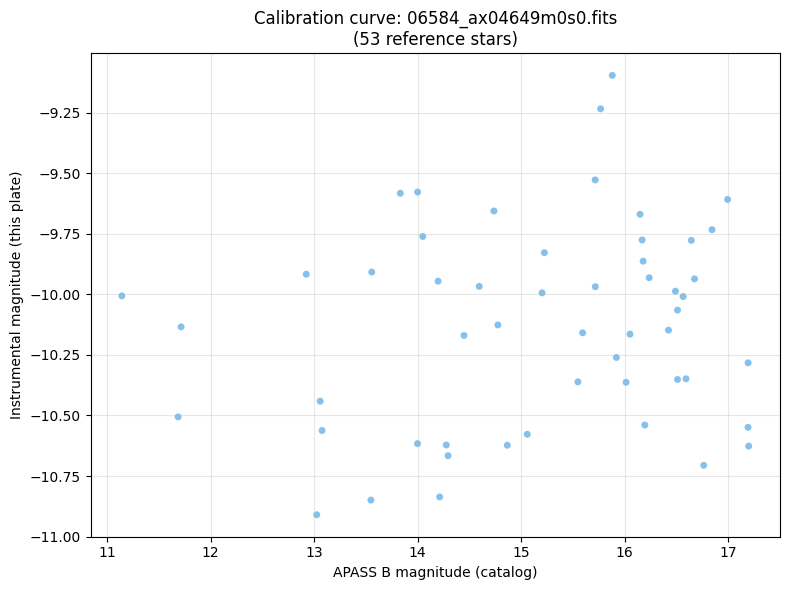

In [6]:
# NOTE: Standalone diagnostic cell - deep dive on ONE specific plate,
# comparing what our pipeline did vs what DASCH did. Set PLATE_FILENAME
# below, or leave as None to auto-pick the worst mismatch from Cell A's
# saved comparison output (run Cell A first if using auto-pick).

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

V_CRA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA")

PLATE_FILENAME = "06584_ax04649m0s0.fits"  # e.g. "03385_mf22262m0s0.fits" - set this to inspect a specific plate

comparison_path = V_CRA_DIR / '02_A' / 'plate_by_plate_comparison.csv'
if PLATE_FILENAME is None:
    if not comparison_path.exists():
        raise FileNotFoundError("Run Cell A (plate comparison) first, or set PLATE_FILENAME manually above.")
    comp_df = pd.read_csv(comparison_path)
    PLATE_FILENAME = comp_df.sort_values('abs_diff_mag', ascending=False)['filename'].iloc[0]
    print(f"No PLATE_FILENAME set - auto-picked the worst mismatch from Cell A: {PLATE_FILENAME}")

def extract_exp_id(filename):
    stem = Path(filename).stem
    parts = stem.split('_', 1)
    return parts[1] if len(parts) == 2 else stem

exp_id = extract_exp_id(PLATE_FILENAME)
print(f"Inspecting plate: {PLATE_FILENAME}  (exp_id={exp_id})")

# --- Our own measurement for this plate ---
results_df = pd.read_csv(V_CRA_DIR / '02_A' / 'vcra_photometry_results.csv')
our_row = results_df[results_df['filename'] == PLATE_FILENAME]
print("\n=== OUR PIPELINE ===")
if len(our_row) == 0:
    print("  Not found in our results - check the filename.")
else:
    print(our_row.T.to_string(header=False))

ref_df = pd.read_csv(V_CRA_DIR / '02_A' / 'vcra_reference_photometry.csv')
plate_refs = ref_df[ref_df['filename'] == PLATE_FILENAME]
print(f"\n  {len(plate_refs)} reference stars used for calibration on this plate")

# --- DASCH's own measurement for this plate ---
from daschlab import Session
sess = Session(str(V_CRA_DIR))
sess.select_target("V CrA")
sess.select_refcat("apass")
dlc = sess.lightcurve(0)
exposures = sess.exposures()

dasch_row = None
for local_id in np.unique(dlc['exp_local_id']):
    if local_id < 0:
        continue
    try:
        if exposures[int(local_id)].exp_id() == exp_id:
            mask = dlc['exp_local_id'] == local_id
            dasch_row = dlc[mask]
            break
    except Exception:
        continue

print("\n=== DASCH ===")
if dasch_row is None or len(dasch_row) == 0:
    print("  DASCH has no record for this exact exp_id.")
else:
    for col in dasch_row.colnames:
        try:
            print(f"  {col}: {dasch_row[col][0]}")
        except Exception:
            pass

# --- Calibration curve for this specific plate ---
if len(plate_refs) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(plate_refs['apass_b_mag'], plate_refs['instrumental_mag'],
               s=25, alpha=0.6, color='#3498db', edgecolor='none')
    ax.set_xlabel('APASS B magnitude (catalog)')
    ax.set_ylabel('Instrumental magnitude (this plate)')
    ax.set_title(f'Calibration curve: {PLATE_FILENAME}\n({len(plate_refs)} reference stars)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo reference-star rows found for this plate in vcra_reference_photometry.csv")

In [10]:
# NOTE: Standalone diagnostic cell - continues from diagnose_target_miss.py.
# Loads the REAL reference-star data for this plate (already saved from
# the actual run) and reproduces calibrate_global + invert_calibration
# exactly, to see whether the target's instrumental magnitude falls
# outside the range the fit was actually built on.

from pathlib import Path
import numpy as np
import pandas as pd

V_CRA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA")
PLATE_FILENAME = "06584_ax04649m0s0.fits"

_run_folders = sorted([d for d in V_CRA_DIR.iterdir() if d.is_dir() and d.name.startswith('run_')])
if _run_folders and (_run_folders[-1] / 'vcra_reference_photometry.csv').exists():
    RUN_DIR = _run_folders[-1]
elif (V_CRA_DIR / '02_A' / 'vcra_reference_photometry.csv').exists():
    RUN_DIR = V_CRA_DIR / '02_A'
else:
    raise FileNotFoundError(f"Couldn't find vcra_reference_photometry.csv under {V_CRA_DIR}")
print(f"Using run output folder: {RUN_DIR}")

ref_df = pd.read_csv(RUN_DIR / 'vcra_reference_photometry.csv')
plate_refs = ref_df[ref_df['filename'] == PLATE_FILENAME]
print(f"{len(plate_refs)} reference stars for this plate")
print(f"Reference star APASS B magnitude range: {plate_refs['apass_b_mag'].min():.2f} to "
      f"{plate_refs['apass_b_mag'].max():.2f}")

# The target's instrumental magnitude, from the previous diagnostic's flux
t_flux = 7823.4  # from diagnose_target_miss.py output
t_inst_mag = -2.5 * np.log10(t_flux)
print(f"\nTarget's instrumental magnitude: {t_inst_mag:.3f}")
print(f"(compare against the reference stars' instrumental_mag range below)")
print(f"Reference star instrumental_mag range: {plate_refs['instrumental_mag'].min():.3f} to "
      f"{plate_refs['instrumental_mag'].max():.3f}")

if t_inst_mag < plate_refs['instrumental_mag'].min():
    print("\n*** Target is BRIGHTER (more negative) than every reference star used for calibration. ***")
    print("*** The fit is being asked to extrapolate beyond the range it was built on. ***")

# --- Reproduce calibrate_global exactly ---
OUTLIER_SIGMA = 3.0
MIN_REF_STARS = 25

def calibrate_global(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x, y = apass_b[mask], inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    coeffs = calibration['coeffs']
    poly = list(coeffs)
    poly[-1] = poly[-1] - t_inst_mag
    roots = np.roots(poly)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    print(f"  All roots of the fit polynomial: {roots}")
    print(f"  Real roots only: {real_roots}")
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    best = min(candidates, key=lambda r: abs(np.polyval(coeffs, r) - t_inst_mag))
    return float(best)

calibration_global = calibrate_global(plate_refs['instrumental_mag'].values, plate_refs['apass_b_mag'].values)
if calibration_global is None:
    print("\ncalibrate_global returned None (fewer than MIN_REF_STARS survived outlier clipping)")
else:
    print(f"\ncalibrate_global succeeded: n_used={calibration_global['n_used']}, "
          f"rms={calibration_global['rms']:.4f}")
    print(f"Fit built on B magnitude range: {calibration_global['b_min']:.2f} to {calibration_global['b_max']:.2f}")
    print(f"Fit coefficients (quadratic, inst_mag = f(B)): {calibration_global['coeffs']}")
    print(f"\nInverting for t_inst_mag={t_inst_mag:.3f}:")
    rough_mag = invert_calibration(calibration_global, t_inst_mag)
    print(f"\nResult: {rough_mag}")
    if rough_mag is None:
        print("*** invert_calibration returned None - NO REAL ROOT exists for this instrumental magnitude ***")
        print("*** given this specific quadratic fit. This is why target_detected stayed False. ***")
    else:
        print(f"Recovered B magnitude estimate: {rough_mag:.3f}")

Using run output folder: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\02_A
53 reference stars for this plate
Reference star APASS B magnitude range: 11.14 to 17.20

Target's instrumental magnitude: -9.733
(compare against the reference stars' instrumental_mag range below)
Reference star instrumental_mag range: -10.910 to -9.096

calibrate_global succeeded: n_used=53, rms=0.4052
Fit built on B magnitude range: 11.14 to 17.20
Fit coefficients (quadratic, inst_mag = f(B)): [-9.47438727e-03  3.25153341e-01 -1.28591467e+01]

Inverting for t_inst_mag=-9.733:
  All roots of the fit polynomial: [17.15959735+5.9543499j 17.15959735-5.9543499j]
  Real roots only: []

Result: None
*** invert_calibration returned None - NO REAL ROOT exists for this instrumental magnitude ***
*** given this specific quadratic fit. This is why target_detected stayed False. ***
